In [10]:
import boto3
import sagemaker

# 1. Initialize environment variables
session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name

# 2. Define Project Tracking Variables
TEAM_ID = "team14"
STUDENT_ID = "s1401"
BUCKET = "nyp-26s1-iti113"
PROJECT_NAME = "airbnb-instant-booking"

PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"
PIPELINE_ROOT = f"s3://{BUCKET}/{PREFIX}/pipeline"
MODEL_PACKAGE_GROUP = f"{TEAM_ID}-{PROJECT_NAME}"

sm_client = boto3.client('sagemaker', region_name=region)

# 3. Fetch the latest registered model from your Model Package Group
print("Fetching model registry details...")
pkgs = sm_client.list_model_packages(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    SortBy='CreationTime', 
    SortOrder='Descending', 
    MaxResults=1
)['ModelPackageSummaryList']

if not pkgs:
    raise ValueError("No model packages found! Ensure the pipeline registered the model.")

pkg_arn = pkgs[0]['ModelPackageArn']
package_desc = sm_client.describe_model_package(ModelPackageName=pkg_arn)

# 4. Extract the S3 URI of the model.tar.gz
model_artifact_s3_uri = package_desc["InferenceSpecification"]["Containers"][0]["ModelDataUrl"]

print(f"✓ Retrieved Model S3 URI: {model_artifact_s3_uri}")

Fetching model registry details...
✓ Retrieved Model S3 URI: s3://sagemaker-ap-southeast-1-044528205969/sagemaker-scikit-learn-2026-08-21-16-52-59-754/pipelines-059euzj1rjtu-RegisterModel-Repack-EqaR9hFOqW/output/model.tar.gz


In [13]:
%%writefile src/shap_explain.py
import subprocess
import sys

# 1. Pin ALL interconnected dependencies to pre-NumPy 2.0 versions
subprocess.check_call([
    sys.executable, "-m", "pip", "install", 
    "numpy<2.0", "numba<0.60.0", "shap==0.44.0", "matplotlib<3.8"
])

import os
import tarfile
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

def main():
    model_dir = "/opt/ml/processing/model"
    data_dir = "/opt/ml/processing/data"
    output_dir = "/opt/ml/processing/output"
    
    # 2. Unpack the SageMaker Model
    with tarfile.open(os.path.join(model_dir, "model.tar.gz"), "r:gz") as tar:
        tar.extractall(path=model_dir)
        
    model_pipeline = joblib.load(os.path.join(model_dir, "model.joblib"))
    preprocessor = model_pipeline.named_steps["preprocessor"]
    classifier = model_pipeline.named_steps["classifier"]
    
    # 3. Load the preprocessed Test Data
    df_test = pd.read_csv(os.path.join(data_dir, "test.csv"))
    df_test.pop("instant_bookable")
    
    # 4. Apply the ColumnTransformer
    X_transformed = preprocessor.transform(df_test)
    clean_features = [col.replace("num__", "").replace("cat__", "") for col in preprocessor.get_feature_names_out()]
    X_trans_df = pd.DataFrame(X_transformed, columns=clean_features, index=df_test.index)
    
    # 5. Calculate SHAP (subsampled for speed)
    explainer = shap.TreeExplainer(classifier)
    X_sample = X_trans_df.sample(min(500, len(X_trans_df)), random_state=42)
    shap_values = explainer(X_sample)
    
    # Extract Class 1 (instant_bookable = 1)
    shap_values_class1 = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
        
    # 6. Generate and Save Plots
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values_class1, max_display=15, show=False)
    plt.title("SHAP Summary Plot — Instant Booking Drivers")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "shap_summary_plot.png"))
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values_class1[0], max_display=12, show=False)
    plt.title("SHAP Waterfall Plot for Sample Listing")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "shap_waterfall_plot.png"))

if __name__ == "__main__":
    main()

Overwriting src/shap_explain.py


INFO:sagemaker.image_uris:Defaulting to only available Python version: py3


INFO:sagemaker:Creating processing-job with name iti113-team14-s1401-shap-2026-08-22-14-57-46-925


Launching SHAP Processing Job... (This takes ~4-5 minutes)


.

.

...

.

.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.4/533.4 kB 25.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 63.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 87.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 MB 63.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 85.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.3 MB/s  0:00:00


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✓ SHAP analysis complete and saved to S3.

1. GLOBAL EXPLAINABILITY (BEESWARM PLOT)


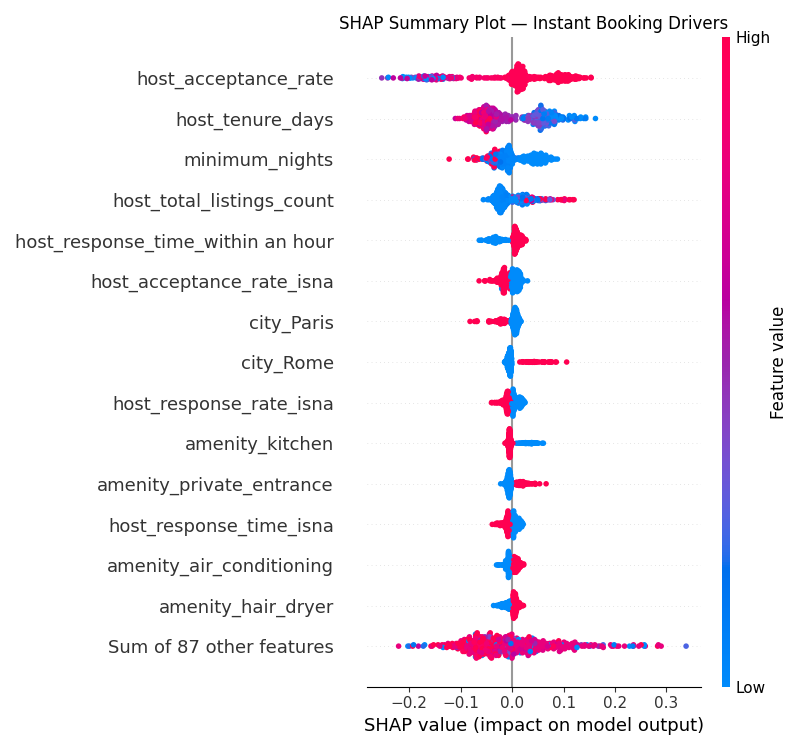


2. LOCAL EXPLAINABILITY (WATERFALL PLOT)


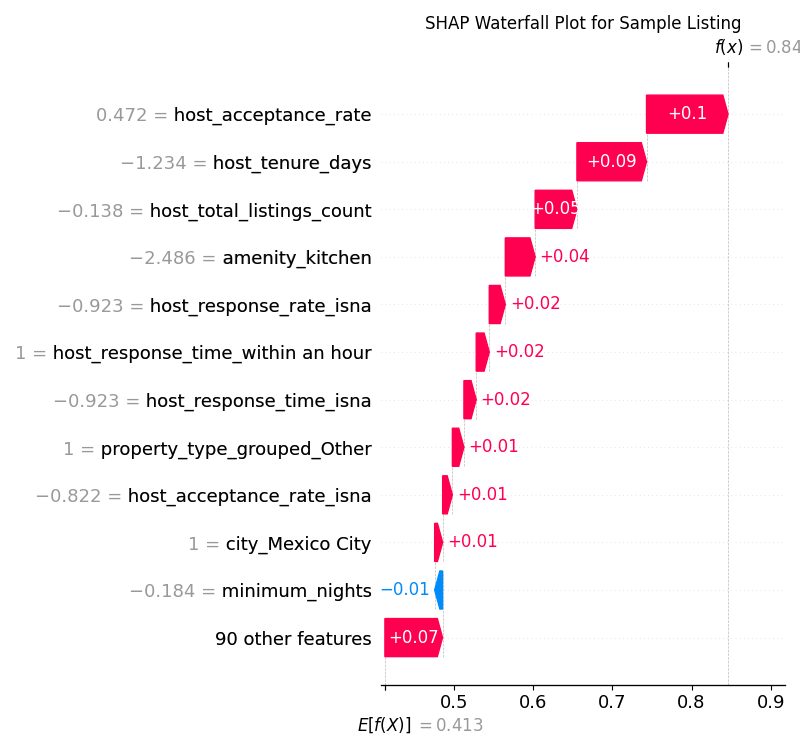

In [14]:
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.processing import ProcessingInput, ProcessingOutput
from IPython.display import Image, display
import boto3

# 1. Initialize exact same processor environment used in training
shap_processor = SKLearnProcessor(
    framework_version="1.2-1",
    instance_type="ml.m5.large",
    instance_count=1,
    role=role,
    sagemaker_session=session,
    base_job_name=f"iti113-{TEAM_ID}-{STUDENT_ID}-shap"
)

print("Launching SHAP Processing Job... (This takes ~4-5 minutes)")

# 2. Run the processing job
shap_processor.run(
    code="src/shap_explain.py",
    inputs=[
        ProcessingInput(
            source=model_artifact_s3_uri,  
            destination="/opt/ml/processing/model"
        ),
        ProcessingInput(
            source=f"{PIPELINE_ROOT}/processed/test.csv",  
            destination="/opt/ml/processing/data"
        )
    ],
    outputs=[
        ProcessingOutput(
            output_name="shap_plots",
            source="/opt/ml/processing/output",
            destination=f"s3://{BUCKET}/{PREFIX}/shap_analysis"
        )
    ],
    wait=True
)
print("✓ SHAP analysis complete and saved to S3.")

# 3. Download and Display Results
print("\nDownloading SHAP visualizations...")
s3_client = boto3.client("s3")

s3_client.download_file(
    Bucket=BUCKET, 
    Key=f"{PREFIX}/shap_analysis/shap_summary_plot.png", 
    Filename="shap_summary_plot.png"
)

s3_client.download_file(
    Bucket=BUCKET, 
    Key=f"{PREFIX}/shap_analysis/shap_waterfall_plot.png", 
    Filename="shap_waterfall_plot.png"
)

print("=" * 80)
print("1. GLOBAL EXPLAINABILITY (BEESWARM PLOT)")
print("=" * 80)
display(Image(filename="shap_summary_plot.png"))

print("\n" + "=" * 80)
print("2. LOCAL EXPLAINABILITY (WATERFALL PLOT)")
print("=" * 80)
display(Image(filename="shap_waterfall_plot.png"))

In [15]:
# ## Pipeline debug

# # Replace with the exact job name from your error message
# failed_job_name = "iti113-team14-s1401-shap-2026-08-22-14-49-33-954"

# print(f"Fetching logs for: {failed_job_name}\n")
# print("-" * 80)
# # This will print the raw container output to help you debug
# session.logs_for_processing_job(failed_job_name, wait=False)